# 分类回归实战_打包训练类Train

实战步骤：

1、加载数据集，理解数据集 fashion_minst

2、搭建 class NeuralNetwork 模型

3、设置交叉熵损失函数，SGD 优化器

4、编写评估函数 evaluating

5、编写训练函数 train

6、开始训练 训练多少次

7、绘制损失、准确率曲线

## 1. 数据集预处理

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

# 定义数据预处理：将图像转换为Tensor，并进行归一化到[0, 1]
transform = transforms.ToTensor()

# 加载数据集
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 定义DataLoader参数
batch_size = 64

# 创建DataLoader对数据进行分批
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 示例：打印一个batch的形状
images, labels = next(iter(train_loader))
print("训练集一个batch的图像形状:", images.shape)
print("训练集一个batch的标签形状:", labels.shape)

print("第一个batch中的第一个tensor：")
print(images[0])



训练集一个batch的图像形状: torch.Size([64, 1, 28, 28])
训练集一个batch的标签形状: torch.Size([64])
第一个batch中的第一个tensor：
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0078, 0.0000, 0.0039, 0.1216, 0.0078, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.4941, 0.7961, 0.0941, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0196, 0.0000, 0.2275, 0.8980, 0.6706, 0.6588, 0.6588,
          0.6314, 0.6275, 0.6431, 0.6196, 0.6275, 0.6431, 0.6471, 0.6902,
          0.6353, 0.7255, 0.1608, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0118, 0.000

## 2. 搭建模型

In [2]:
from torch import nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  # 展平输入，[batch, 1, 28, 28] -> [batch, 28*28]
        self.fc1 = nn.Linear(28*28, 300)  # 第一全连接层，将784维输入映射到300维
        self.relu1 = nn.ReLU()  # 第一ReLU激活函数
        self.fc2 = nn.Linear(300, 100)  # 第二全连接层，将300维输入映射到100维
        self.relu2 = nn.ReLU()  # 第二ReLU激活函数
        self.fc3 = nn.Linear(100, 10)  # 输出层，将100维输入映射到10个类别

    # 前向传播方法，调用 model(x) 会自动调用 forward(x)
    def forward(self, x):
        x = self.flatten(x)
        # print("经过flatten后形状:", x.shape)
        x = self.fc1(x)
        # print("经过fc1后形状:", x.shape)
        x = self.relu1(x)
        # print("经过relu1后形状:", x.shape)
        x = self.fc2(x)
        # print("经过fc2后形状:", x.shape)
        x = self.relu2(x)
        # print("经过relu2后形状:", x.shape)
        x = self.fc3(x)
        # print("经过fc3后形状:", x.shape)
        return x


In [3]:
# 模型测试

# 随机生成一个数据，形状为 (1, 1, 28, 28)
random_input = torch.randn(1, 1, 28, 28)

# 实例化模型
model = NeuralNetwork()

# 调用模型进行前向传播
output = model(random_input)

print("模型输出：")
print(output)


模型输出：
tensor([[-0.0555,  0.0550, -0.0894,  0.1563, -0.0149,  0.1234,  0.0307, -0.1037,
          0.0984, -0.0676]], grad_fn=<AddmmBackward0>)


## 3. 封装Trainer类进行训练与评估

Trainer 初始化完成
设备: cuda
损失函数: CrossEntropyLoss()
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
训练集: 60000 个样本, 938 个批次
验证集: 10000 个样本, 157 个批次

开始训练模型
训练轮数: 40
训练集: 60000 个样本, 938 个批次
验证集: 10000 个样本, 157 个批次
设备: cuda
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)

Epoch [1/40], Train Loss: 0.6884, Train Acc: 0.7602, Val Loss: 0.5316, Val Acc: 0.8132
Epoch [2/40], Train Loss: 0.4288, Train Acc: 0.8468, Val Loss: 0.4304, Val Acc: 0.8456
Epoch [3/40], Train Loss: 0.3807, Train Acc: 0.8618, Val Loss: 0.4100, Val Acc: 0.8501
Epoch [4/40], Train Loss: 0.3498, Train Acc: 0.8724, Val Loss: 0.3964, Val Acc: 0.8533
Epoch [5/40], Train Loss: 0.3303, Train Acc: 0.8800, Val Loss: 0.3736, Val Acc: 0.8

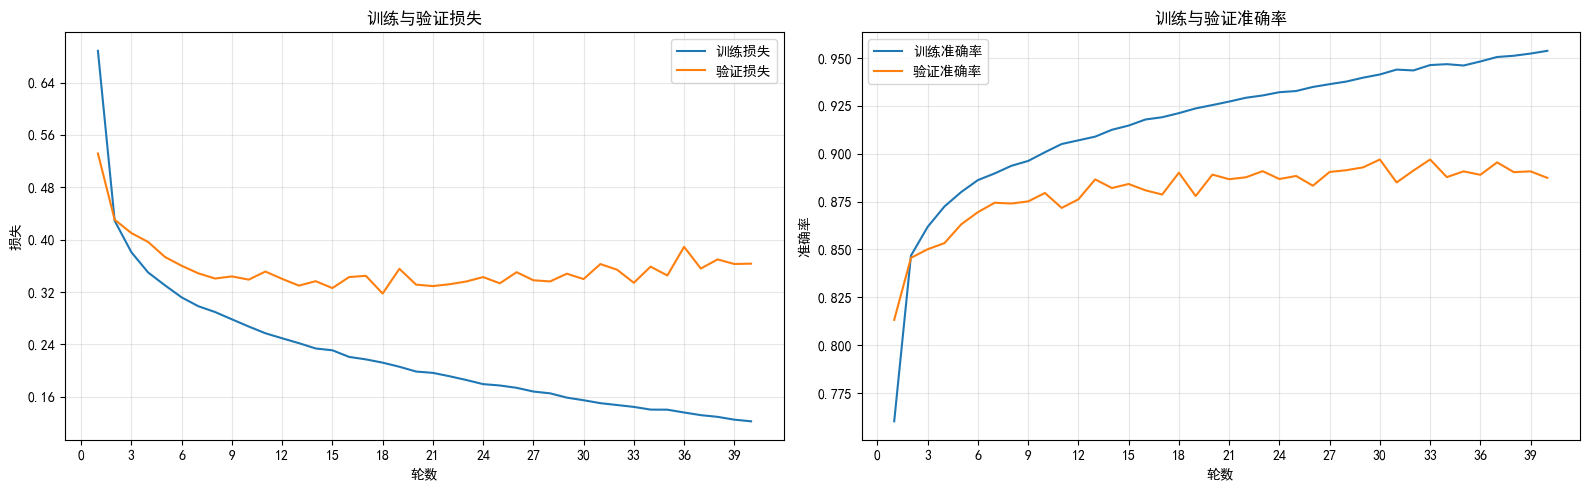

训练历史曲线绘制完成！


In [4]:
# 导入 Trainer 模块
from Train import Trainer
import torch.optim as optim

# 创建新的模型实例（如果之前已经训练过，可以创建新模型重新训练）
model_with_trainer = NeuralNetwork()

# 创建 Trainer 实例，传入模型和数据加载器
trainer = Trainer(
    model=model_with_trainer,
    train_loader=train_loader,
    val_loader=test_loader
)

# 开始训练（使用 Trainer 类）
num_epochs = 40
trainer.train(num_epochs=num_epochs)

# 使用 Trainer 进行最终评估
print("\n" + "=" * 60)
print("最终模型评估")
print("=" * 60)
final_loss, final_acc = trainer.evaluating()
print(f"最终测试损失: {final_loss:.4f}")
print(f"最终测试准确率: {final_acc:.4f}")

# 使用 Trainer 绘制训练历史曲线
trainer.plot_history()



## Trainer 类使用说明

### 方式1：初始化时传入数据加载器（推荐，更简洁）
```python
trainer = Trainer(model, train_loader=train_loader, val_loader=test_loader)
trainer.train(num_epochs=10)  # 无需再传数据加载器
trainer.evaluating()  # 使用默认的验证集
trainer.plot_history()  # 绘制训练曲线
```

### 方式2：在方法中传入数据加载器（更灵活）
```python
trainer = Trainer(model)
trainer.train(train_loader, test_loader, num_epochs=10)  # 可以传入不同的数据
trainer.evaluating(test_loader)  # 可以评估不同的数据集
trainer.plot_history()
```

### Trainer 类的优势
- ✅ 封装了训练、评估、可视化功能
- ✅ 自动记录训练历史
- ✅ 详细的提示信息
- ✅ 支持灵活的数据加载器传入方式
- ✅ 自动处理设备（CPU/GPU）转换

